# Практическая работа №2
## Titanic, группировка и сравнение

**Цель:** исследовать набор данных о пассажирах Titanic, сравнить различные группы пассажиров и сформулировать выводы.

Исходный файл: `train.csv`.

## Задание 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Датасет загружен в DataFrame `df`. В таблице находятся сведения о пассажирах Titanic.

## Задание 2. Знакомство с датасетом

In [2]:
print("Количество строк и столбцов:", df.shape)
print("\nНазвания столбцов:")
print(df.columns.tolist())
print("\nТипы данных:")
df.dtypes

Количество строк и столбцов: (891, 12)

Названия столбцов:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных:


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

В датасете **891 строк и 12 столбцов**. Столбцы содержат сведения о выживании, классе, имени, поле, возрасте, стоимости билета и другие данные о пассажирах.

## Задание 3. Анализ пассажиров

In [3]:
print("Количество пассажиров по классам:")
print(df["Pclass"].value_counts().sort_index())
print("\nКоличество мужчин и женщин:")
print(df["Sex"].value_counts())

df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 18, 30, 50, np.inf],
                        labels=["до 18", "18–30", "31–50", "51+"], right=False)
print("\nКоличество пассажиров по возрастным группам:")
print(df["AgeGroup"].value_counts().reindex(["до 18", "18–30", "31–50", "51+"]))
print("\nСредний возраст:", round(df["Age"].mean(), 2))
print("Медианный возраст:", round(df["Age"].median(), 2))
print("Средняя стоимость билета:", round(df["Fare"].mean(), 2))

Количество пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Количество мужчин и женщин:
Sex
male      577
female    314
Name: count, dtype: int64

Количество пассажиров по возрастным группам:
AgeGroup
до 18    113
18–30    271
31–50    256
51+       74
Name: count, dtype: int64

Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


**Результаты:** 1 класс — 216, 2 класс — 184, 3 класс — 491; мужчин — 577, женщин — 314; средний возраст — **29.70 года**; медианный возраст — **28 лет**; средняя стоимость билета — **32.20**.

Возраст разделён на группы до 18, 18–30, 31–50 и 51+ лет. Для части пассажиров возраст не указан, поэтому не все 891 строки попадают в возрастные группы.

## Задание 4. Сравнение пассажиров разных классов

In [4]:
class_comparison = df.groupby("Pclass").agg(
    Количество=("PassengerId", "count"),
    Средняя_стоимость_билета=("Fare", "mean"),
    Средний_возраст=("Age", "mean")
).round(2)
class_comparison

,Количество,Средняя_стоимость_билета,Средний_возраст
Pclass,,,
1,216,84.15,38.23
2,184,20.66,29.88
3,491,13.68,25.14


In [5]:
print("Мужчины и женщины по классам:")
pd.crosstab(df["Pclass"], df["Sex"])

Мужчины и женщины по классам:


Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


In [6]:
print("Самый дорогой билет:")
df.loc[df["Fare"].idxmax(), ["Name", "Fare", "Pclass", "Age", "Sex", "Survived", "Ticket"]]

Самый дорогой билет:


Name        Ward, Miss. Anna
Fare                512.3292
Pclass                     1
Age                     35.0
Sex                   female
Survived                   1
Ticket              PC 17755
Name: 258, dtype: object

**Вывод по классам:** больше всего пассажиров было в 3 классе — **491 человек**. Средняя стоимость билета была выше в 1 классе (**84.15**), чем во 2 (**20.66**) и 3 (**13.68**) классах. Средний возраст также был выше у пассажиров 1 класса.

Самый дорогой билет стоил **512.3292**. Это пассажир 1 класса, женщина, возраст **35 лет**; пассажир выжил.

## Задание 5. Анализ выживаемости

In [7]:
print("Общее количество погибших и выживших:")
print(df["Survived"].value_counts().rename(index={0: "Погибли", 1: "Выжили"}))

print("\nВыживаемость мужчин и женщин:")
survival_sex = df.groupby("Sex")["Survived"].agg(Количество="count", Выжившие="sum", Доля_выживших="mean")
survival_sex["Доля_выживших"] = (survival_sex["Доля_выживших"] * 100).round(2)
survival_sex

Общее количество погибших и выживших:
Survived
Погибли    549
Выжили     342
Name: count, dtype: int64

Выживаемость мужчин и женщин:


,Количество,Выжившие,Доля_выживших
Sex,,,
female,314,233,74.20
male,577,109,18.89


In [8]:
print("Выживаемость мужчин и женщин в каждом классе:")
survival_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].agg(
    Количество="count", Выжившие="sum", Доля_выживших="mean")
survival_class_sex["Доля_выживших"] = (survival_class_sex["Доля_выживших"] * 100).round(2)
survival_class_sex

Выживаемость мужчин и женщин в каждом классе:


Количество  Выжившие  Доля_выживших
Pclass Sex                                        
1      female          94        91          96.81
       male           122        45          36.89
2      female          76        70          92.11
       male           108        17          15.74
3      female         144        72          50.00
       male           347        47          13.54

**Вывод:** всего выжило **342** пассажиров, погибло **549**. Доля выживших среди женщин составила **74.20%**, среди мужчин — **18.89%**.

Если разделить пассажиров одновременно по полу и классу, наибольшая доля выживших была среди **женщин 1 класса — 96.81%**.

## Задание 6. Визуализация

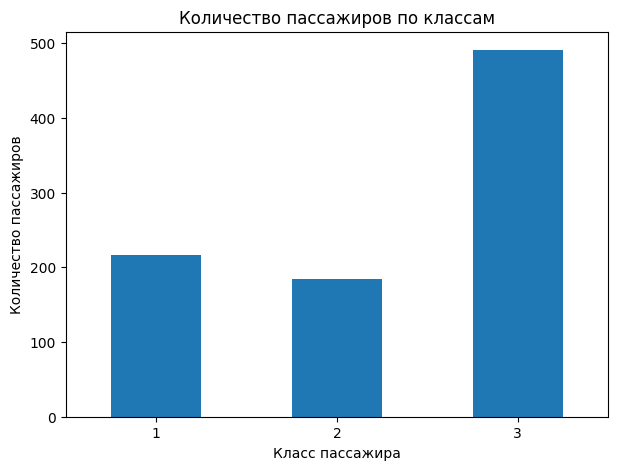

In [9]:
plt.figure(figsize=(7, 5))
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Количество пассажиров по классам")
plt.xlabel("Класс пассажира")
plt.ylabel("Количество пассажиров")
plt.xticks(rotation=0)
plt.show()

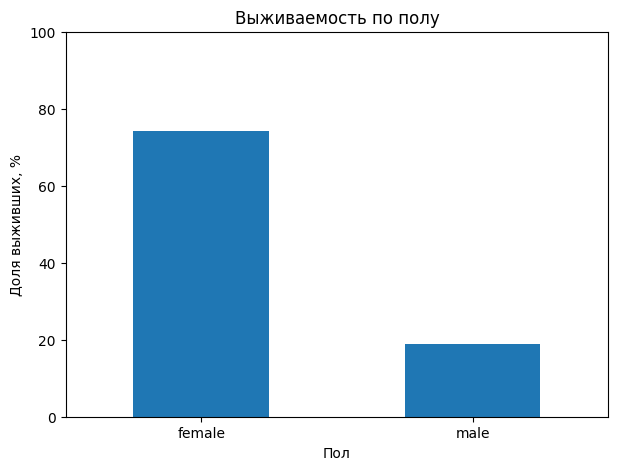

In [10]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
plt.figure(figsize=(7, 5))
survival_by_sex.plot(kind="bar")
plt.title("Выживаемость по полу")
plt.xlabel("Пол")
plt.ylabel("Доля выживших, %")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

### Собственный вопрос
**Влияет ли наличие родственников на борту на долю выживших?**

Разделим пассажиров на тех, кто путешествовал один, и тех, у кого на борту были супруги, братья/сёстры, родители или дети.

In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"]
df["Группа"] = np.where(df["FamilySize"] == 0, "Один", "С родственниками")
family_survival = df.groupby("Группа")["Survived"].agg(
    Количество="count", Выжившие="sum", Доля_выживших="mean")
family_survival["Доля_выживших"] = (family_survival["Доля_выживших"] * 100).round(2)
family_survival

,Количество,Выжившие,Доля_выживших
Группа,,,
Один,537,163,30.35
С родственниками,354,179,50.56


По этому сравнению среди пассажиров, путешествовавших с родственниками, доля выживших составила **50.56%**, а среди путешествовавших одних — **30.35%**. В данном датасете группа путешествовавших с родственниками имеет более высокую долю выживших.

## Итоговый вывод

В ходе практической работы был исследован датасет Titanic с помощью Pandas. Были определены размеры и структура набора данных, количество пассажиров разных классов и полов, возрастные группы, средний и медианный возраст, а также средняя стоимость билета.

Сравнение классов показало, что пассажиров больше всего в 3 классе, при этом средняя стоимость билета и средний возраст выше в 1 классе. Анализ выживаемости показал различия между мужчинами и женщинами и между классами. Наибольшая доля выживших среди групп, разделённых по классу и полу, наблюдалась у женщин 1 класса.

Дополнительный анализ показал различие в доле выживших между пассажирами, путешествовавшими одними, и пассажирами, путешествовавшими с родственниками.